# Shark Tank India — Data Analysis & Statistical Modeling

**Author:** Mayank
**Dataset:** Shark Tank India, Season 1 & 2 (pitch-level data)

This notebook walks through a full analyst-style investigation of the Shark
Tank India dataset: cleaning the raw data, exploring it, asking concrete
business questions, testing them statistically, building two simple
interpretable models, and closing with a set of business insights and a
spec for a Power BI dashboard.

## 1. Business Problem / Objective

Shark Tank India has run for multiple seasons, and every pitch generates a
rich record: what the founders asked for, what they actually got, which
sharks invested, and how the deal terms changed from the ask.

Stakeholders (say, the show's production/analytics team, or an aspiring
founder studying the show) would care about questions like:

- How often do pitches actually convert into deals, and has that changed
  across seasons?
- Which industries and which sharks are the most active investors, and are
  those differences big enough to matter or just noise?
- Does asking for a more aggressive valuation hurt or help your odds of
  getting a deal?
- What pitch characteristics are associated with getting a deal at all?

The goal of this notebook is to answer these with the actual data — clean
it, explore it, test the questions statistically where it's appropriate,
build a couple of simple models, and be explicit about what the data can
and can't tell us (this is observational TV data, not a designed
experiment).

## 2. Dataset Overview

Pitch-level data for Shark Tank India Seasons 1 and 2, one row per startup
pitch. It includes the ask (amount, equity, implied valuation), whether an
offer was received/accepted, the final deal terms, and per-shark investment
amounts for the seven main sharks plus occasional guest sharks.

Source: compiled from public Shark Tank India episode data
(https://github.com/Siddharth-94/EDA-On-Shark-Tank-India-Data), covering
Season 1 (Dec 2021 – Feb 2022) and Season 2 (Jan–Mar 2023).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
df_raw = pd.read_csv('data/shark_tank_india_raw.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (321, 74)


,Season Number,Startup Name,Season Start,Season End,Episode Number,Episode Title,Anchor,Pitch Number,Industry,Business Description,Company Website,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Pitchers Average Age,Started in,Pitchers City,Pitchers State,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,Original Ask Amount,Original Offered Equity,Valuation Requested,Received Offer,Accepted Offer,Total Deal Amount,Total Deal Equity,Total Deal Debt,Debt Interest,Deal Valuation,Number of sharks in deal,Deal has conditions,Has Patents,Ashneer Investment Amount,Ashneer Investment Equity,Ashneer Debt Amount,Namita Investment Amount,Namita Investment Equity,Namita Debt Amount,Anupam Investment Amount,Anupam Investment Equity,Anupam Debt Amount,Vineeta Investment Amount,Vineeta Investment Equity,Vineeta Debt Amount,Aman Investment Amount,Aman Investment Equity,Aman Debt Amount,Peyush Investment Amount,Peyush Investment Equity,Peyush Debt Amount,Ghazal Investment Amount,Ghazal Investment Equity,Ghazal Debt Amount,Amit Investment Amount,Amit Investment Equity,Amit Debt Amount,Guest Investment Amount,Guest Investment Equity,Guest Debt Amount,Guest Name,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
0,1,BluePineFoods,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,1,Food,Frozen Momos,https://bluepinefoods.com/,3,2.0,1.0,NaN,0.0,Middle,2016.0,Delhi,Delhi,95.0,8.0,NaN,NaN,50.0,5.0,1000.0,1,1.0,75.0,16.00,NaN,NaN,469.0,3.0,NaN,NaN,25.0,5.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,5.33,NaN,25.0,5.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,1,BoozScooters,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,2,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,https://www.boozup.net/,1,1.0,NaN,NaN,0.0,Young,2017.0,Ahmedabad,Gujarat,4.0,0.4,NaN,NaN,40.0,15.0,267.0,1,1.0,40.0,50.00,NaN,NaN,80.0,2.0,NaN,NaN,20.0,25.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,25.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,1,HeartUpMySleeves,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,3,Beauty/Fashion,Detachable Sleeves,https://heartupmysleeves.com/,1,NaN,1.0,NaN,0.0,Young,2021.0,Delhi,Delhi,NaN,2.0,NaN,NaN,25.0,10.0,250.0,1,1.0,25.0,30.00,NaN,NaN,83.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,15.0,NaN,12.5,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
3,1,TagzFoods,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,4,Food,Healthy Potato Chips Snacks,https://tagzfoods.com/,2,2.0,NaN,NaN,0.0,Middle,2019.0,Bangalore,Karnataka,700.0,NaN,48.0,NaN,70.0,1.0,7000.0,1,1.0,70.0,2.75,NaN,NaN,2545.0,1.0,NaN,NaN,70.0,2.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
4,1,HeadAndHeart,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,5,Education,Brain Development Course,https://thehnh.in/,4,1.0,3.0,NaN,1.0,Middle,2015.0,Patiala,Punjab,30.0,NaN,NaN,NaN,50.0,5.0,1000.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              321 non-null    int64  
 1   Startup Name               321 non-null    str    
 2   Season Start               321 non-null    str    
 3   Season End                 321 non-null    str    
 4   Episode Number             321 non-null    int64  
 5   Episode Title              321 non-null    str    
 6   Anchor                     321 non-null    str    
 7   Pitch Number               321 non-null    int64  
 8   Industry                   321 non-null    str    
 9   Business Description       321 non-null    str    
 10  Company Website            310 non-null    str    
 11  Number of Presenters       321 non-null    int64  
 12  Male Presenters            282 non-null    float64
 13  Female Presenters          150 non-null    float64
 14  Trans

74 columns is a lot, but most of the width comes from having one
investment-amount / investment-equity / investment-debt / present column
for each of the 9 possible sharks (7 regular + 1 replacement + 1 guest).
The core pitch-level fields are much smaller. Let's look at those first.

In [4]:
core_cols = ['Season Number', 'Startup Name', 'Episode Number', 'Industry',
             'Business Description', 'Number of Presenters', 'Pitchers Average Age',
             'Pitchers City', 'Pitchers State', 'Original Ask Amount',
             'Original Offered Equity', 'Valuation Requested', 'Received Offer',
             'Accepted Offer', 'Total Deal Amount', 'Total Deal Equity',
             'Deal Valuation', 'Number of sharks in deal']
df_raw[core_cols].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Season Number,321.0,NaN,NaN,NaN,1.52648,0.500078,1.0,1.0,2.0,2.0,2.0
Startup Name,321,321,BluePineFoods,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Episode Number,321.0,NaN,NaN,NaN,21.482866,14.702695,0.0,9.0,21.0,33.0,51.0
Industry,321,16,Food,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Business Description,321,320,Healthy Snacks,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Presenters,321.0,NaN,NaN,NaN,2.077882,0.846044,1.0,2.0,2.0,2.0,6.0
Pitchers Average Age,321,3,Middle,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pitchers City,321,79,Mumbai,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pitchers State,321,34,Maharashtra,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Original Ask Amount,321.0,NaN,NaN,NaN,168.663555,1671.576903,0.0,50.0,65.0,100.0,30000.0


In [5]:
print('Duplicate rows:', df_raw.duplicated().sum())
print('Duplicate startup names:', df_raw['Startup Name'].duplicated().sum())
print()
print('Missing values (columns with any missing), top 20:')
miss = df_raw.isna().mean().sort_values(ascending=False) * 100
print(miss[miss > 0].head(20).round(1))

Duplicate rows: 0
Duplicate startup names: 0

Missing values (columns with any missing), top 20:
Ghazal Debt Amount           100.0
Ashneer Debt Amount           99.4
Guest Name                    99.4
Guest Debt Amount             99.4
Guest Investment Equity       99.4
Guest Investment Amount       99.4
Transgender Presenters        99.1
Anupam Debt Amount            98.8
Amit Debt Amount              98.8
Guest Present                 98.4
Has Patents                   97.8
Aman Debt Amount              97.5
Ghazal Investment Amount      97.5
Deal has conditions           97.5
Ghazal Investment Equity      97.5
Vineeta Debt Amount           97.2
Peyush Debt Amount            96.6
Namita Debt Amount            96.0
Ashneer Investment Amount     93.5
Ashneer Investment Equity     93.5
dtype: float64


No duplicate rows or duplicate startup names — good. A lot of columns are
mostly missing, but that's expected here rather than a data quality
problem: a shark's "Investment Amount" column is only populated for the
handful of pitches that shark actually invested in, so >90% missing on
those columns is normal, not something to fix. We'll deal with the columns
that matter for analysis in the cleaning step below.

## 3. Data Cleaning & Preparation

We keep `df_raw` untouched and build a working copy, `df`, with the fixes
and derived columns we actually need. Each step below is justified by
something we saw in the raw data, not applied by default.

### 3.1 Data types

`Season Start` / `Season End` are strings that should be dates. `Received
Offer` is 0/1 but really a boolean. `Pitchers Average Age` is a category
(Young / Middle / Old), not free text to clean.

In [6]:
df = df_raw.copy()

df['Season Start'] = pd.to_datetime(df['Season Start'], format='%d-%b-%y')
df['Season End'] = pd.to_datetime(df['Season End'], format='%d-%b-%y')

df['Received Offer'] = df['Received Offer'].astype(bool)
df['Industry'] = df['Industry'].str.strip()
df['Pitchers Average Age'] = df['Pitchers Average Age'].astype('category')

print(df['Industry'].nunique(), 'industries:')
print(sorted(df['Industry'].unique()))

16 industries:
['Agriculture', 'Animal/Pets', 'Beauty/Fashion', 'Education', 'Electronics', 'Entertainment', 'Food', 'Furnishing/Household', 'Hardware', 'Liquor/Beverages', 'Manufacturing', 'Medical/Health', 'Services', 'Sports', 'Technology/Software', 'Vehicles/Electrical Vehicles']


Industry names are already consistent (no case/whitespace duplicates like
"food" vs "Food "), so no re-mapping is needed there.

### 3.2 Deal outcome — defining "Deal" cleanly

`Received Offer` (did any shark make an offer) and `Accepted Offer` (did
the founder accept it) are two different questions. `Accepted Offer` is
NaN exactly when no offer was received (checked below), and 0/1 otherwise.
For analysis we want one unambiguous flag: **did the startup walk away
with a deal**.

In [7]:
# sanity check: Accepted Offer should only be NaN when Received Offer is False
check = pd.crosstab(df['Received Offer'], df['Accepted Offer'].isna())
print(check)
assert (df.loc[~df['Received Offer'], 'Accepted Offer'].isna()).all()
assert df.loc[df['Received Offer'], 'Accepted Offer'].isna().sum() == 0

df['deal_closed'] = (df['Accepted Offer'] == 1)
print()
print(df['deal_closed'].value_counts())
print(f"Deal conversion rate: {df['deal_closed'].mean():.1%}")

Accepted Offer  False  True 
Received Offer              
False               0    104
True              217      0

deal_closed
True     176
False    145
Name: count, dtype: int64
Deal conversion rate: 54.8%


217 pitches got at least one offer, but 41 of those were not accepted (the
founder walked away, or terms fell through), so the true "deal" count is
176 out of 321 — a 54.8% conversion rate. We'll use `deal_closed` as the
target variable everywhere below instead of `Received Offer`.

### 3.3 Fixing a known inconsistency

One row has an investment amount recorded for Aman but a missing
"present" flag — clearly he was present if he invested, so we fix that
rather than drop the row.

In [8]:
sharks = ['Ashneer', 'Namita', 'Anupam', 'Vineeta', 'Aman', 'Peyush', 'Ghazal', 'Amit', 'Guest']

inconsistent = df[(df['Aman Investment Amount'].notna()) & (df['Aman Present'] != 1)]
print('Rows with an investment but no presence flag:', len(inconsistent))
df.loc[inconsistent.index, 'Aman Present'] = 1

Rows with an investment but no presence flag: 1


### 3.4 Checking the ask valuation for internal consistency

`Valuation Requested` should equal `Original Ask Amount / Original Offered
Equity * 100`. If it doesn't, the data has an error worth knowing about.

In [9]:
implied_val = df['Original Ask Amount'] / df['Original Offered Equity'] * 100
gap_pct = (implied_val - df['Valuation Requested']).abs() / df['Valuation Requested'].replace(0, np.nan)
print('Rows where implied and stated valuation differ by more than 1%:', (gap_pct > 0.01).sum())
df.loc[gap_pct > 0.01, ['Startup Name', 'Original Ask Amount', 'Original Offered Equity', 'Valuation Requested']]

Rows where implied and stated valuation differ by more than 1%: 0


,Startup Name,Original Ask Amount,Original Offered Equity,Valuation Requested


Essentially all rows are internally consistent (rounding aside), so the
ask-side numbers can be trusted as-is.

### 3.5 Outliers

`Gopal's56` (Season 1) asked for ₹300 crore (30,000 lakh) at a ₹1,200 crore
valuation — an order of magnitude above every other pitch. That's a real,
reported figure, not a data-entry artifact (equity/valuation math checks
out), so we keep the row but will use log scales / medians rather than
means in places where a single outlier like this would distort the
picture.

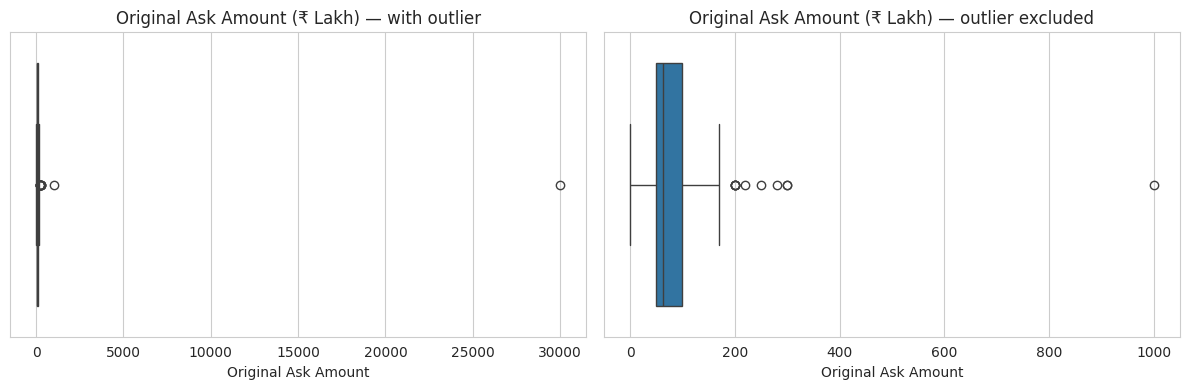

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Original Ask Amount'], ax=axes[0])
axes[0].set_title('Original Ask Amount (₹ Lakh) — with outlier')
sns.boxplot(x=df.loc[df['Startup Name'] != "Gopal's56", 'Original Ask Amount'], ax=axes[1])
axes[1].set_title('Original Ask Amount (₹ Lakh) — outlier excluded')
plt.tight_layout()
plt.show()

### 3.6 Missing values that matter

For pitch-level fields (not the per-shark investment columns, whose
missingness is structural and fine as-is), here's what's actually missing
and how we're handling it:

- `Yearly Revenue`, `Monthly Sales`, `Gross Margin`, `Net Margin`: many
  founders don't disclose financials on the show, or they're pre-revenue.
  We leave these as NaN (not 0 — 0 revenue and "not disclosed" are
  different things) and only use them in analyses that explicitly say so.
- `Total Deal Amount`, `Total Deal Equity`, `Deal Valuation`, `Number of
  sharks in deal`: NaN for the 145 pitches with no closed deal — this is
  structural, not a gap to fill.
- `Male Presenters` / `Female Presenters`: NaN when that gender wasn't
  present in the founding team at all (i.e. an all-female team has NaN in
  `Male Presenters`). We fill with 0 for founder-composition analysis.
- `Started in` (founding year): kept as-is; not central to this analysis.

In [11]:
df['Male Presenters'] = df['Male Presenters'].fillna(0)
df['Female Presenters'] = df['Female Presenters'].fillna(0)
df['Couple Presenters'] = df['Couple Presenters'].fillna(0)

print('Missing values remaining in core analysis columns:')
core_check = ['Original Ask Amount', 'Original Offered Equity', 'Valuation Requested',
              'Industry', 'Season Number', 'deal_closed', 'Total Deal Amount']
print(df[core_check].isna().sum())

Missing values remaining in core analysis columns:
Original Ask Amount          0
Original Offered Equity      0
Valuation Requested          0
Industry                     0
Season Number                0
deal_closed                  0
Total Deal Amount          145
dtype: int64


### 3.7 Derived columns

A few columns that make the rest of the notebook much easier to write and
are each used somewhere below:

In [12]:
df['season_label'] = 'Season ' + df['Season Number'].astype(str)

# log versions of heavily right-skewed money columns, for plots/models
df['log_ask_amount'] = np.log1p(df['Original Ask Amount'])
df['log_valuation_requested'] = np.log1p(df['Valuation Requested'])
df['log_deal_amount'] = np.log1p(df['Total Deal Amount'])

# how much of the ask amount was actually funded, and how valuation moved (deals only)
df['pct_of_ask_funded'] = df['Total Deal Amount'] / df['Original Ask Amount']
df['valuation_change_pct'] = (df['Deal Valuation'] - df['Valuation Requested']) / df['Valuation Requested']

# team composition
df['team_size_bucket'] = pd.cut(df['Number of Presenters'], bins=[0, 1, 2, 10],
                                 labels=['Solo founder', 'Two founders', '3+ founders'])

# high vs low valuation ask, split at the median — used in the A/B section
median_valuation = df['Valuation Requested'].median()
df['valuation_ask_group'] = np.where(df['Valuation Requested'] >= median_valuation,
                                      'High valuation ask', 'Low valuation ask')

print(f'Median valuation ask: ₹{median_valuation:,.0f} lakh')
df[['Startup Name', 'season_label', 'pct_of_ask_funded', 'valuation_change_pct',
    'team_size_bucket', 'valuation_ask_group']].sample(5, random_state=RANDOM_SEED)

Median valuation ask: ₹2,000 lakh


,Startup Name,season_label,pct_of_ask_funded,valuation_change_pct,team_size_bucket,valuation_ask_group
173,AtypicalAdvantage,Season 2,1.0,-0.666667,Solo founder,High valuation ask
132,Glii,Season 1,NaN,NaN,3+ founders,Low valuation ask
197,Sepal,Season 2,1.0,-0.500000,Two founders,High valuation ask
9,CosIQ,Season 1,1.0,-0.700150,Two founders,Low valuation ask
104,ExperentialEtc,Season 1,NaN,NaN,Two founders,High valuation ask


### 3.8 Per-shark long format

For shark-level analysis (investment by shark, deals by shark) it's much
easier to work with one row per (pitch, shark that invested) instead of
wide per-shark columns. We build that as a separate long table,
`shark_deals`, rather than reshaping the main `df`.

In [13]:
shark_rows = []
for s in sharks:
    amt_col, eq_col = f'{s} Investment Amount', f'{s} Investment Equity'
    if amt_col not in df.columns:
        continue
    sub = df.loc[df[amt_col].notna(), ['Startup Name', 'season_label', 'Industry',
                                        'Total Deal Amount', amt_col, eq_col]].copy()
    sub['shark'] = s
    sub = sub.rename(columns={amt_col: 'investment_amount', eq_col: 'investment_equity'})
    shark_rows.append(sub)

shark_deals = pd.concat(shark_rows, ignore_index=True).drop(columns=['Total Deal Amount'])
print(shark_deals.shape)
shark_deals.head()

(354, 6)


,Startup Name,season_label,Industry,investment_amount,investment_equity,shark
0,BluePineFoods,Season 1,Food,25.0,5.33,Ashneer
1,BoozScooters,Season 1,Vehicles/Electrical Vehicles,20.0,25.00,Ashneer
2,TagzFoods,Season 1,Food,70.0,2.75,Ashneer
3,SkippiIcePops,Season 1,Food,20.0,3.00,Ashneer
4,RaisingSuperstars,Season 1,Education,50.0,2.00,Ashneer


`shark_deals` has one row per shark per pitch they co-invested in, so a
pitch with 3 sharks contributes 3 rows — that's what we want for "number of
deals by shark" and "average deal size by shark".

## 4. Exploratory Data Analysis

### 4.1 Headline numbers

In [14]:
deals = df[df['deal_closed']].copy()

total_pitches = len(df)
total_deals = len(deals)
conversion_rate = total_deals / total_pitches
total_investment = deals['Total Deal Amount'].sum()
avg_deal = deals['Total Deal Amount'].mean()
median_deal = deals['Total Deal Amount'].median()

print(f'Total pitches:          {total_pitches}')
print(f'Total deals closed:     {total_deals}')
print(f'Deal conversion rate:   {conversion_rate:.1%}')
print(f'Total investment:       ₹{total_investment:,.1f} lakh (~₹{total_investment/100:,.1f} crore)')
print(f'Average deal size:      ₹{avg_deal:,.1f} lakh')
print(f'Median deal size:       ₹{median_deal:,.1f} lakh')

Total pitches:          321
Total deals closed:     176
Deal conversion rate:   54.8%
Total investment:       ₹11,005.6 lakh (~₹110.1 crore)
Average deal size:      ₹62.5 lakh
Median deal size:       ₹50.0 lakh


In [15]:
print(f'Average deal (₹{avg_deal:,.1f} lakh) vs median deal (₹{median_deal:,.1f} lakh) — '
      f'the gap between them is a first sign the deal-size distribution is right-skewed, '
      f'which we confirm properly in section 4.3. This is also why we report both, and lean '
      f'on the median when describing a \"typical\" deal.')

Average deal (₹62.5 lakh) vs median deal (₹50.0 lakh) — the gap between them is a first sign the deal-size distribution is right-skewed, which we confirm properly in section 4.3. This is also why we report both, and lean on the median when describing a "typical" deal.


### 4.2 Deal vs No-Deal

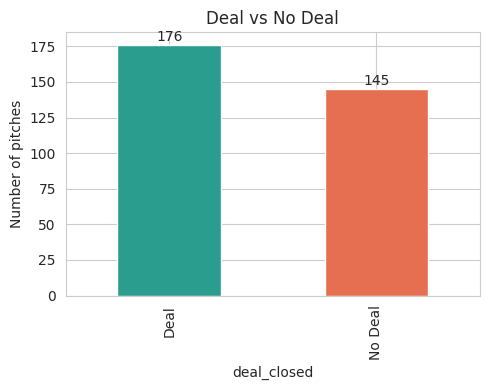

In [16]:
outcome_counts = df['deal_closed'].map({True: 'Deal', False: 'No Deal'}).value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
outcome_counts.plot(kind='bar', color=['#2a9d8f', '#e76f51'], ax=ax)
ax.set_title('Deal vs No Deal')
ax.set_ylabel('Number of pitches')
for i, v in enumerate(outcome_counts):
    ax.text(i, v + 3, str(v), ha='center')
plt.tight_layout()
plt.show()

### 4.3 Distribution of deal amounts

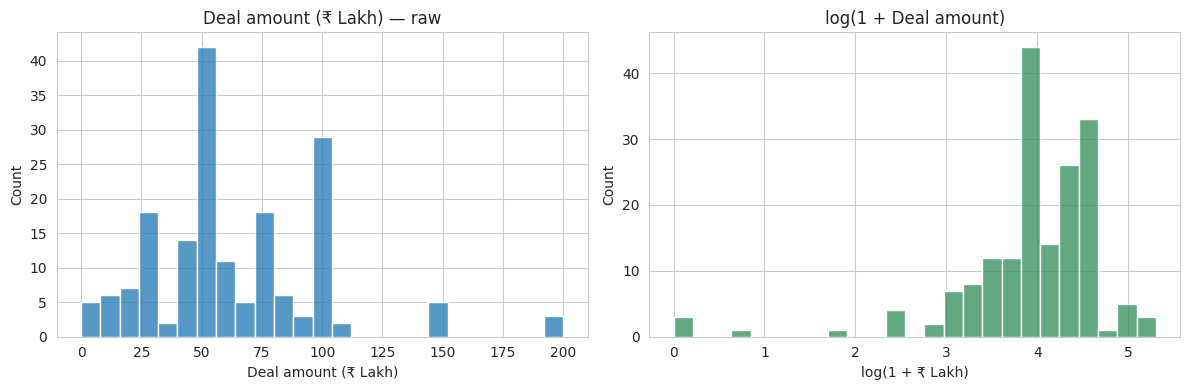

Skewness of deal amount: 1.13


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(deals['Total Deal Amount'], bins=25, ax=axes[0])
axes[0].set_title('Deal amount (₹ Lakh) — raw')
axes[0].set_xlabel('Deal amount (₹ Lakh)')

sns.histplot(np.log1p(deals['Total Deal Amount']), bins=25, ax=axes[1], color='seagreen')
axes[1].set_title('log(1 + Deal amount)')
axes[1].set_xlabel('log(1 + ₹ Lakh)')
plt.tight_layout()
plt.show()

print('Skewness of deal amount:', round(stats.skew(deals['Total Deal Amount']), 2))

Deal amount is right-skewed (a long tail of large deals), which is normal
for money data. This is the main reason we'll lean on median-based and
rank-based statistics (Mann-Whitney, Spearman) rather than assuming
normality later in the notebook.

### 4.4 By season: pitches, deals, and investment

In [18]:
season_summary = df.groupby('season_label').agg(
    pitches=('Startup Name', 'count'),
    deals=('deal_closed', 'sum'),
).assign(conversion_rate=lambda x: x['deals'] / x['pitches'])
season_summary['total_investment'] = deals.groupby('season_label')['Total Deal Amount'].sum()
season_summary['avg_deal_size'] = deals.groupby('season_label')['Total Deal Amount'].mean()
season_summary

,pitches,deals,conversion_rate,total_investment,avg_deal_size
season_label,,,,,
Season 1,152,70,0.460526,4024.60106,57.494301
Season 2,169,106,0.627219,6981.00000,65.858491


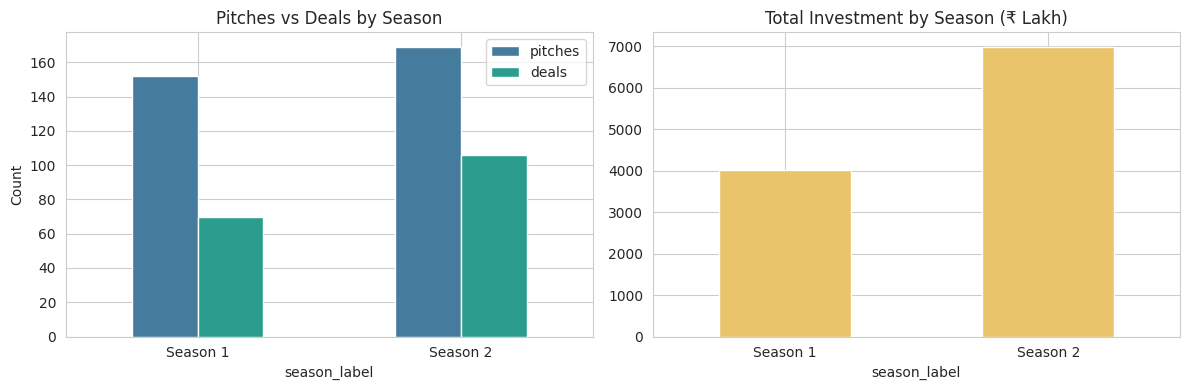

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
season_summary[['pitches', 'deals']].plot(kind='bar', ax=axes[0], color=['#457b9d', '#2a9d8f'])
axes[0].set_title('Pitches vs Deals by Season')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

season_summary['total_investment'].plot(kind='bar', ax=axes[1], color='#e9c46a')
axes[1].set_title('Total Investment by Season (₹ Lakh)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 4.5 Investment and deals by Shark

In [20]:
shark_summary = shark_deals.groupby('shark').agg(
    num_deals=('Startup Name', 'count'),
    total_investment=('investment_amount', 'sum'),
    avg_deal_size=('investment_amount', 'mean'),
    median_deal_size=('investment_amount', 'median'),
    avg_equity_pct=('investment_equity', 'mean'),
).sort_values('total_investment', ascending=False)
shark_summary.round(1)

,num_deals,total_investment,avg_deal_size,median_deal_size,avg_equity_pct
shark,,,,,
Aman,73,2510.0,34.4,32.5,3.6
Peyush,69,2210.4,32.0,26.7,6.1
Namita,66,2097.5,31.8,25.8,4.6
Anupam,51,1451.2,28.5,25.0,6.0
Vineeta,43,1170.6,27.2,25.0,5.6
Amit,21,800.9,38.1,30.0,5.2
Ashneer,21,539.3,25.7,20.0,4.4
Ghazal,8,160.0,20.0,22.5,6.5
Guest,2,65.5,32.8,32.8,1.5


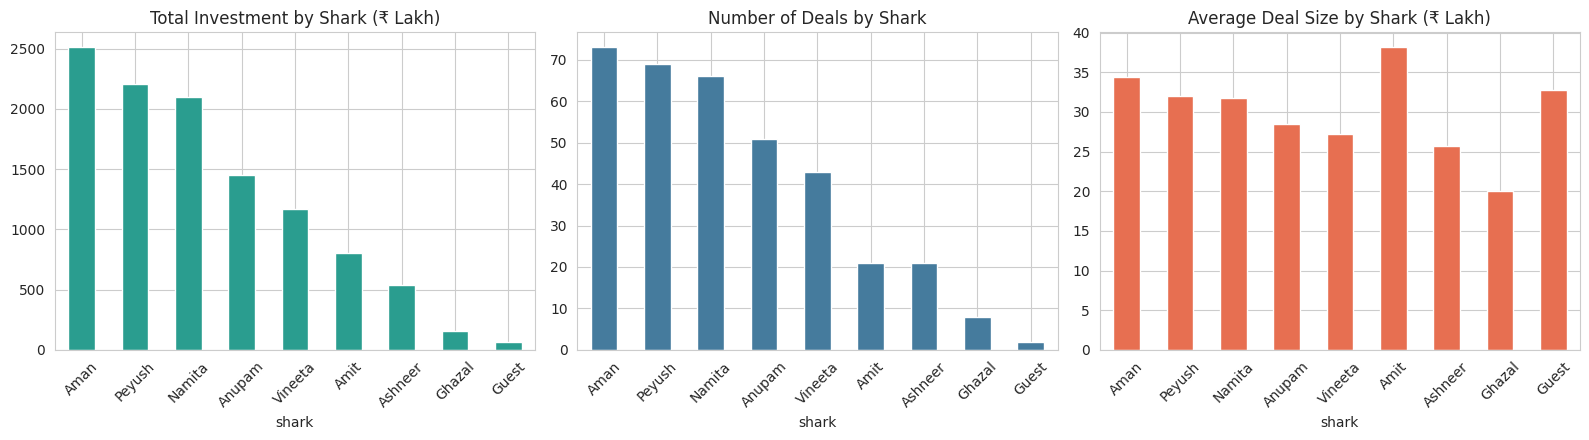

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

shark_summary['total_investment'].plot(kind='bar', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Total Investment by Shark (₹ Lakh)')
axes[0].tick_params(axis='x', rotation=45)

shark_summary['num_deals'].plot(kind='bar', ax=axes[1], color='#457b9d')
axes[1].set_title('Number of Deals by Shark')
axes[1].tick_params(axis='x', rotation=45)

shark_summary['avg_deal_size'].plot(kind='bar', ax=axes[2], color='#e76f51')
axes[2].set_title('Average Deal Size by Shark (₹ Lakh)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Note: Ashneer and Ghazal only appear in Season 1 and Amit only joined in
Season 2 (matches the show's actual lineup changes), so raw deal counts
aren't a fully fair comparison across sharks who weren't on the panel the
same number of episodes — worth flagging rather than ignoring.

### 4.6 Investment and success rate by Industry

In [22]:
industry_summary = df.groupby('Industry').agg(
    pitches=('Startup Name', 'count'),
    deals=('deal_closed', 'sum'),
).assign(conversion_rate=lambda x: x['deals'] / x['pitches'])
industry_summary['total_investment'] = deals.groupby('Industry')['Total Deal Amount'].sum()
industry_summary['total_investment'] = industry_summary['total_investment'].fillna(0)
industry_summary = industry_summary.sort_values('pitches', ascending=False)
industry_summary.round(2)

,pitches,deals,conversion_rate,total_investment
Industry,,,,
Food,82,44,0.54,2457.6
Beauty/Fashion,58,34,0.59,1972.0
Manufacturing,38,20,0.53,1141.0
Services,28,12,0.43,1032.0
Technology/Software,26,14,0.54,900.0
Medical/Health,24,18,0.75,1517.0
Furnishing/Household,13,5,0.38,225.0
Vehicles/Electrical Vehicles,13,8,0.62,421.0
Education,9,6,0.67,440.0


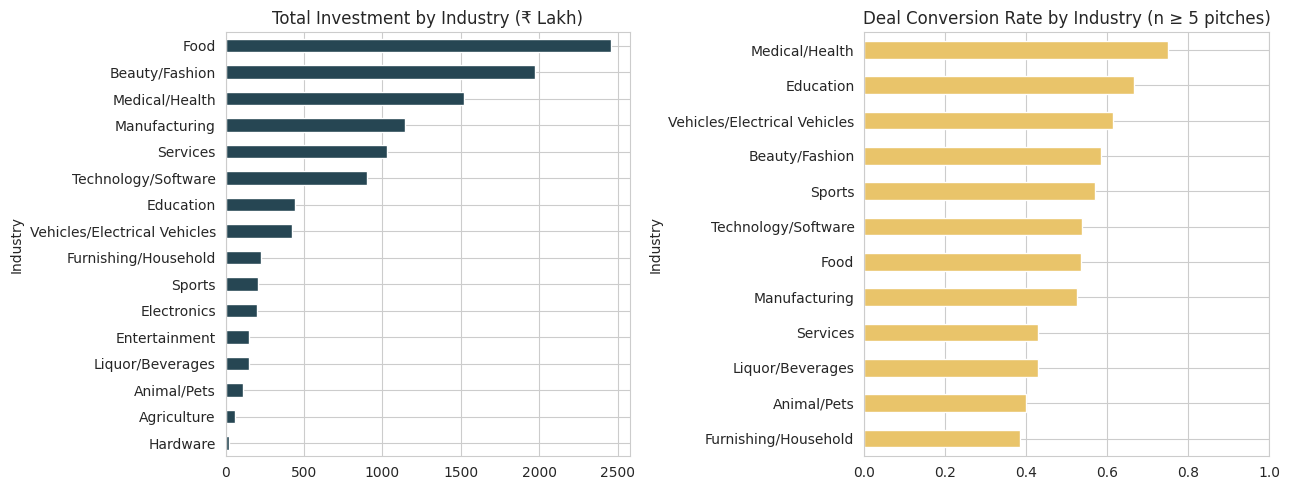

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

industry_summary['total_investment'].sort_values().plot(kind='barh', ax=axes[0], color='#264653')
axes[0].set_title('Total Investment by Industry (₹ Lakh)')

# only show conversion rate for industries with a reasonable sample size
reliable = industry_summary[industry_summary['pitches'] >= 5].sort_values('conversion_rate')
reliable['conversion_rate'].plot(kind='barh', ax=axes[1], color='#e9c46a')
axes[1].set_title('Deal Conversion Rate by Industry (n ≥ 5 pitches)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

Several industries (Hardware, Entertainment, Agriculture) have only 2–3
pitches — their conversion rates are shown in the table but excluded from
the chart above and shouldn't be read as reliable industry-level signal.

### 4.7 Ask vs Deal: amount, valuation, equity

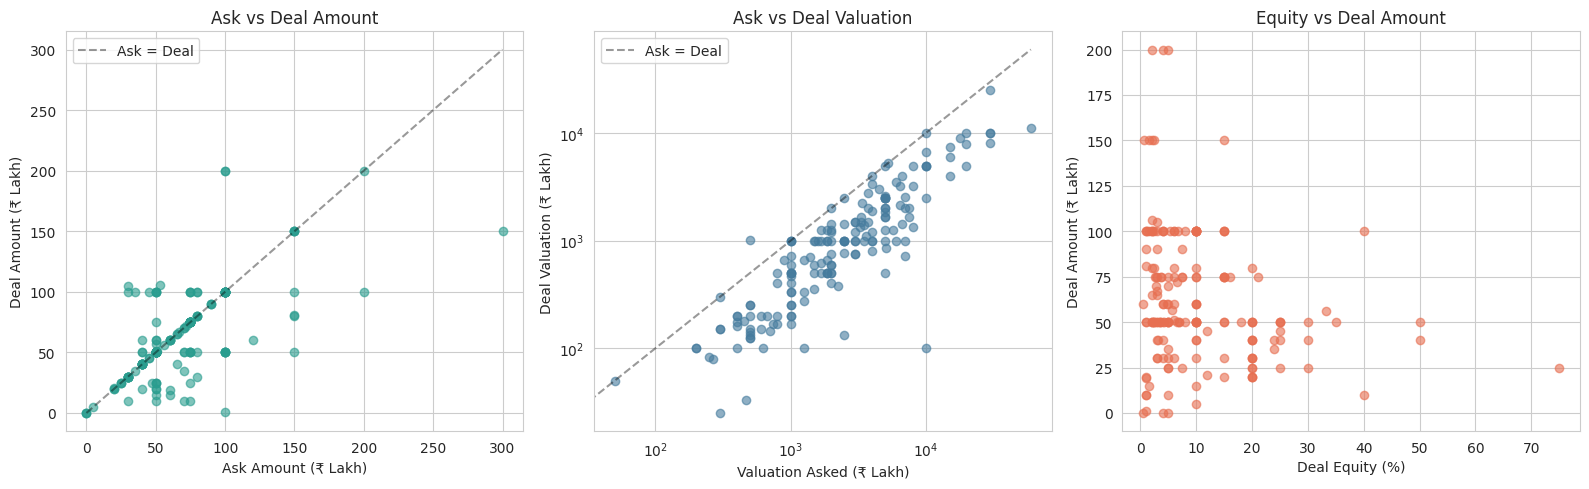

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(deals['Original Ask Amount'], deals['Total Deal Amount'], alpha=0.6, color='#2a9d8f')
lim = max(deals['Original Ask Amount'].max(), deals['Total Deal Amount'].max())
axes[0].plot([0, lim], [0, lim], 'k--', alpha=0.4, label='Ask = Deal')
axes[0].set_xlabel('Ask Amount (₹ Lakh)'); axes[0].set_ylabel('Deal Amount (₹ Lakh)')
axes[0].set_title('Ask vs Deal Amount'); axes[0].legend()

axes[1].scatter(deals['Valuation Requested'], deals['Deal Valuation'], alpha=0.6, color='#457b9d')
lim2 = max(deals['Valuation Requested'].max(), deals['Deal Valuation'].max())
axes[1].plot([0, lim2], [0, lim2], 'k--', alpha=0.4, label='Ask = Deal')
axes[1].set_xlabel('Valuation Asked (₹ Lakh)'); axes[1].set_ylabel('Deal Valuation (₹ Lakh)')
axes[1].set_title('Ask vs Deal Valuation'); axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].legend()

axes[2].scatter(deals['Total Deal Equity'], deals['Total Deal Amount'], alpha=0.6, color='#e76f51')
axes[2].set_xlabel('Deal Equity (%)'); axes[2].set_ylabel('Deal Amount (₹ Lakh)')
axes[2].set_title('Equity vs Deal Amount')

plt.tight_layout()
plt.show()

Most points sit below the "Ask = Deal" line in both the amount and
valuation panels — consistent with sharks typically negotiating the deal
down from the ask, which we'll quantify properly in the statistical
testing section rather than eyeballing it here.

### 4.8 Correlation between key numeric variables

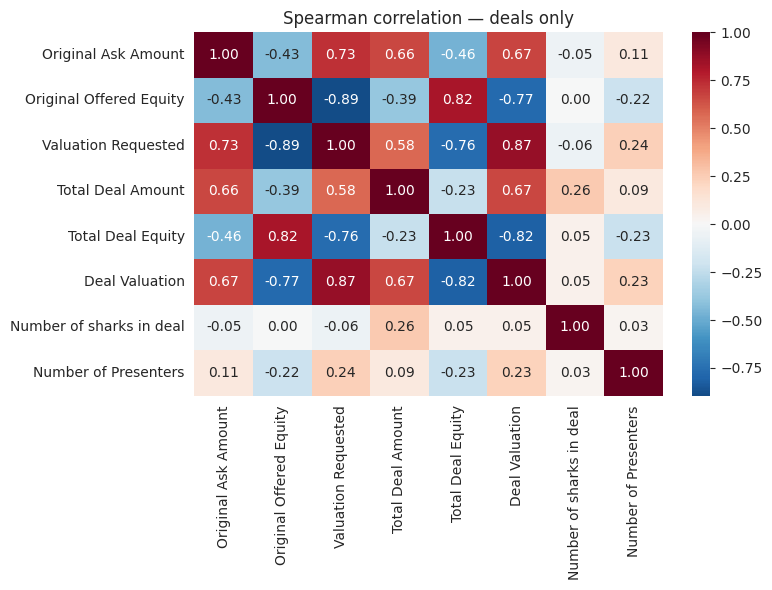

In [25]:
num_cols = ['Original Ask Amount', 'Original Offered Equity', 'Valuation Requested',
            'Total Deal Amount', 'Total Deal Equity', 'Deal Valuation',
            'Number of sharks in deal', 'Number of Presenters']
corr = deals[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Spearman correlation — deals only')
plt.tight_layout()
plt.show()

We use **Spearman** rather than Pearson here because the underlying money
variables are skewed (Section 4.3) — Spearman only assumes a monotonic
relationship, not linearity or normality, which is a safer default for
this kind of data.

## 5. Business Questions

Based on what's actually in the data (and dropping questions the data
can't support — e.g. there's no real two-way factorial design here, so a
two-way ANOVA isn't a natural fit; and with only 2 seasons, "differences
across seasons" is a two-group comparison, not a multi-group ANOVA), these
are the questions we test in Section 6:

1. Is deal success (deal_closed) associated with industry?
2. Does deal amount differ between Season 1 and Season 2?
3. Do the sharks differ in typical deal size (among sharks who invest)?
4. Is a higher valuation ask associated with a *different* deal
   conversion rate than a lower ask (this becomes the A/B-style
   comparison in Section 8)?
5. Is ask amount correlated with the final deal amount?
6. Is equity offered correlated with deal amount?
7. Are any industries significantly more/less successful at getting deals
   than the overall rate?
8. What pitch-level factors are jointly associated with the probability
   of getting a deal (answered with logistic regression in Section 7)?

We did **not** keep a paired t-test in the plan — there's no natural
before/after pairing of the same startup — and we did not force a
two-proportion test onto every categorical pair; it's used specifically
for the A/B comparison in Section 8 where a binary group split is
meaningful.

## 6. Statistical Analysis

For every test: business question → hypotheses → why this test → checked
assumptions → result → effect size / CI → plain-English interpretation.
We use **alpha = 0.05** throughout, and separate *statistical*
significance from *practical* significance in the interpretation.

We'll collect every p-value into `test_results` as we go, and apply a
multiple-testing correction at the end of this section.

In [26]:
test_results = []  # (question, test_name, p_value)

### 6.1 Does industry have an association with deal success?

**H0:** Deal outcome (deal / no deal) is independent of industry.
**H1:** Deal outcome is associated with industry.

**Why this test:** both variables are categorical → chi-square test of
independence. But several industries have very few pitches, so we check
expected cell counts first (chi-square needs expected counts ≥5 in most
cells to be reliable) and group rare industries together if needed.

In [27]:
industry_deal_ct = pd.crosstab(df['Industry'], df['deal_closed'])
print(industry_deal_ct)

chi2_check, p_check, dof_check, expected = stats.chi2_contingency(industry_deal_ct)
low_expected_pct = (expected < 5).mean()
print(f'\nShare of cells with expected count < 5: {low_expected_pct:.0%}')

deal_closed                   False  True 
Industry                                  
Agriculture                       1      2
Animal/Pets                       3      2
Beauty/Fashion                   24     34
Education                         3      6
Electronics                       2      2
Entertainment                     1      1
Food                             38     44
Furnishing/Household              8      5
Hardware                          1      1
Liquor/Beverages                  4      3
Manufacturing                    18     20
Medical/Health                    6     18
Services                         16     12
Sports                            3      4
Technology/Software              12     14
Vehicles/Electrical Vehicles      5      8

Share of cells with expected count < 5: 50%


In [28]:
# too many sparse cells for a reliable chi-square -> group industries with < 10 pitches into 'Other'
industry_counts = df['Industry'].value_counts()
small_industries = industry_counts[industry_counts < 10].index
df['industry_grouped'] = df['Industry'].where(~df['Industry'].isin(small_industries), 'Other (small n)')

grouped_ct = pd.crosstab(df['industry_grouped'], df['deal_closed'])
print(grouped_ct)

chi2, p_val, dof, expected2 = stats.chi2_contingency(grouped_ct)
print(f'\nChi-square = {chi2:.2f}, dof = {dof}, p-value = {p_val:.4f}')
print(f'Min expected cell count: {expected2.min():.1f}')

# Cramer's V as effect size
n = grouped_ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(grouped_ct.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v:.3f}")

test_results.append(('Industry vs deal success', 'Chi-square test of independence', p_val))

deal_closed                   False  True 
industry_grouped                          
Beauty/Fashion                   24     34
Food                             38     44
Furnishing/Household              8      5
Manufacturing                    18     20
Medical/Health                    6     18
Other (small n)                  18     21
Services                         16     12
Technology/Software              12     14
Vehicles/Electrical Vehicles      5      8

Chi-square = 7.69, dof = 8, p-value = 0.4646
Min expected cell count: 5.9
Cramer's V (effect size): 0.155


In [29]:
alpha = 0.05
if p_val < alpha:
    verdict = 'statistically significant'
else:
    verdict = 'not statistically significant'
print(f'Result is {verdict} at alpha={alpha}.')
print(f"Cramer's V of {cramers_v:.2f} indicates a "
      + ('small' if cramers_v < 0.2 else 'moderate' if cramers_v < 0.4 else 'large')
      + ' effect size (Cramer\'s V benchmarks: ~0.1 small, ~0.3 moderate, ~0.5 large for df like this).')
print()
print('Business interpretation: ' +
      ('Industry appears to matter for whether a pitch gets a deal — some industries convert '
       'meaningfully better than others, beyond what we\'d expect from chance alone.'
       if p_val < alpha else
       'We don\'t have strong enough evidence to say deal success depends on industry — the '
       'differences we saw in the EDA bar chart could plausibly be due to sample-size noise.'))

Result is not statistically significant at alpha=0.05.
Cramer's V of 0.15 indicates a small effect size (Cramer's V benchmarks: ~0.1 small, ~0.3 moderate, ~0.5 large for df like this).

Business interpretation: We don't have strong enough evidence to say deal success depends on industry — the differences we saw in the EDA bar chart could plausibly be due to sample-size noise.


### 6.2 Do deal amounts differ between Season 1 and Season 2?

**H0:** The distribution of deal amounts is the same in Season 1 and
Season 2.
**H1:** The distributions differ.

**Why this test:** deal amount is continuous but right-skewed (Section
4.3), so before picking a t-test vs a non-parametric test we check
normality (Shapiro-Wilk) and equal variance (Levene's test) per season.

In [30]:
s1_deals = deals.loc[deals['Season Number'] == 1, 'Total Deal Amount']
s2_deals = deals.loc[deals['Season Number'] == 2, 'Total Deal Amount']

sw1 = stats.shapiro(s1_deals)
sw2 = stats.shapiro(s2_deals)
levene_stat, levene_p = stats.levene(s1_deals, s2_deals)

print(f'Shapiro-Wilk Season 1: stat={sw1.statistic:.3f}, p={sw1.pvalue:.4f}')
print(f'Shapiro-Wilk Season 2: stat={sw2.statistic:.3f}, p={sw2.pvalue:.4f}')
print(f"Levene's test (equal variance): stat={levene_stat:.3f}, p={levene_p:.4f}")

Shapiro-Wilk Season 1: stat=0.953, p=0.0110
Shapiro-Wilk Season 2: stat=0.894, p=0.0000
Levene's test (equal variance): stat=1.753, p=0.1873


In [31]:
# Both seasons fail the Shapiro-Wilk normality test (p < 0.05) -> use the non-parametric
# Mann-Whitney U test instead of an independent t-test.
u_stat, p_mw = stats.mannwhitneyu(s1_deals, s2_deals, alternative='two-sided')
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_mw:.4f}')
print(f'Season 1 median deal: ₹{s1_deals.median():.1f} lakh (n={len(s1_deals)})')
print(f'Season 2 median deal: ₹{s2_deals.median():.1f} lakh (n={len(s2_deals)})')

# rank-biserial correlation as effect size for Mann-Whitney
r_rb = 1 - (2 * u_stat) / (len(s1_deals) * len(s2_deals))
print(f'Rank-biserial correlation (effect size): {r_rb:.3f}')

test_results.append(('Deal amount: Season 1 vs Season 2', 'Mann-Whitney U', p_mw))

Mann-Whitney U = 3384.5, p-value = 0.3213
Season 1 median deal: ₹50.0 lakh (n=70)
Season 2 median deal: ₹50.0 lakh (n=106)
Rank-biserial correlation (effect size): 0.088


In [32]:
print('Business interpretation: ' +
      (f'Deal sizes differ meaningfully between the two seasons (median ₹{s1_deals.median():.0f} lakh '
       f'vs ₹{s2_deals.median():.0f} lakh).' if p_mw < alpha else
       f'Deal sizes look similar across the two seasons (median ₹{s1_deals.median():.0f} lakh vs '
       f'₹{s2_deals.median():.0f} lakh) — we can\'t reject the idea that any observed gap is noise.'))

Business interpretation: Deal sizes look similar across the two seasons (median ₹50 lakh vs ₹50 lakh) — we can't reject the idea that any observed gap is noise.


### 6.3 Do sharks differ in typical deal size?

**H0:** All sharks have the same distribution of deal (investment) sizes.
**H1:** At least one shark differs.

**Why this test:** more than two groups, continuous but skewed outcome →
Kruskal-Wallis (the non-parametric analogue of one-way ANOVA) instead of
ANOVA, consistent with the non-normality we already found in 6.2. We
restrict to sharks with a reasonable number of deals so the comparison is
meaningful.

In [33]:
shark_deal_counts = shark_deals['shark'].value_counts()
eligible_sharks = shark_deal_counts[shark_deal_counts >= 10].index.tolist()
print('Sharks included (>=10 deals):', eligible_sharks)

groups = [shark_deals.loc[shark_deals['shark'] == s, 'investment_amount'] for s in eligible_sharks]
kw_stat, p_kw = stats.kruskal(*groups)
print(f'\nKruskal-Wallis H = {kw_stat:.2f}, dof = {len(groups)-1}, p-value = {p_kw:.4f}')

# epsilon-squared effect size for Kruskal-Wallis
n_total = sum(len(g) for g in groups)
eps_sq = (kw_stat - len(groups) + 1) / (n_total - len(groups))
print(f'Epsilon-squared (effect size): {eps_sq:.3f}')

test_results.append(('Deal size across sharks', 'Kruskal-Wallis', p_kw))

Sharks included (>=10 deals): ['Aman', 'Peyush', 'Namita', 'Anupam', 'Vineeta', 'Ashneer', 'Amit']

Kruskal-Wallis H = 6.88, dof = 6, p-value = 0.3320
Epsilon-squared (effect size): 0.003


In [34]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

if p_kw < alpha:
    print('Kruskal-Wallis is significant -> running pairwise Mann-Whitney with Benjamini-Hochberg correction:\n')
    pairs, pvals = [], []
    for a, b in combinations(eligible_sharks, 2):
        ga = shark_deals.loc[shark_deals['shark'] == a, 'investment_amount']
        gb = shark_deals.loc[shark_deals['shark'] == b, 'investment_amount']
        _, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
        pairs.append(f'{a} vs {b}')
        pvals.append(p)
    reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
    posthoc = pd.DataFrame({'pair': pairs, 'p_raw': pvals, 'p_adj_bh': p_adj, 'significant': reject})
    print(posthoc.sort_values('p_adj_bh').to_string(index=False))
else:
    print('Kruskal-Wallis is not significant, so we do not run pairwise post-hoc comparisons '
          '(would inflate false positives for no reason).')

Kruskal-Wallis is not significant, so we do not run pairwise post-hoc comparisons (would inflate false positives for no reason).


In [35]:
median_by_shark = shark_deals[shark_deals['shark'].isin(eligible_sharks)].groupby('shark')['investment_amount'].median().sort_values(ascending=False)
print(median_by_shark.round(1))
print()
print('Business interpretation: ' +
      ('Typical deal size genuinely varies by shark — some sharks systematically write bigger '
       'or smaller checks than others, not just due to which pitches they happened to see.'
       if p_kw < alpha else
       'We don\'t find strong evidence that typical deal size varies by shark once we account '
       'for the small samples for some sharks — differences in the EDA chart could be noise.'))

shark
Aman       32.5
Amit       30.0
Peyush     26.7
Namita     25.8
Anupam     25.0
Vineeta    25.0
Ashneer    20.0
Name: investment_amount, dtype: float64

Business interpretation: We don't find strong evidence that typical deal size varies by shark once we account for the small samples for some sharks — differences in the EDA chart could be noise.


### 6.4 Is ask amount associated with final deal amount?

**H0:** No monotonic relationship between ask amount and deal amount
(deals only, ρ = 0).
**H1:** There is a monotonic relationship (ρ ≠ 0).

**Why this test:** both continuous and skewed → Spearman rank
correlation (matches the reasoning in Section 4.8), computed only on
closed deals since deal amount is undefined otherwise.

In [36]:
rho, p_rho = stats.spearmanr(deals['Original Ask Amount'], deals['Total Deal Amount'])
print(f'Spearman rho = {rho:.3f}, p-value = {p_rho:.2e}, n = {len(deals)}')

test_results.append(('Ask amount vs deal amount', 'Spearman correlation', p_rho))

print()
print('Business interpretation: ' +
      (f'Ask amount and deal amount are positively correlated (rho={rho:.2f}) — founders who ask '
       'for more tend to walk away with more, though the relationship is far from 1-to-1 (see the '
       'scatter plot in 4.7, most points sit below the "ask = deal" line).' if p_rho < alpha else
       'We do not find a significant association between ask amount and deal amount.'))

Spearman rho = 0.660, p-value = 2.01e-23, n = 176

Business interpretation: Ask amount and deal amount are positively correlated (rho=0.66) — founders who ask for more tend to walk away with more, though the relationship is far from 1-to-1 (see the scatter plot in 4.7, most points sit below the "ask = deal" line).


### 6.5 Is equity offered related to deal amount?

**H0:** No monotonic relationship between the equity given up in the deal
and the deal amount (ρ = 0).
**H1:** There is a relationship (ρ ≠ 0).

In [37]:
rho_eq, p_eq = stats.spearmanr(deals['Total Deal Equity'], deals['Total Deal Amount'])
print(f'Spearman rho = {rho_eq:.3f}, p-value = {p_eq:.2e}, n = {len(deals)}')

test_results.append(('Deal equity vs deal amount', 'Spearman correlation', p_eq))

print()
print('Business interpretation: ' +
      (f'Equity and deal amount are correlated (rho={rho_eq:.2f}) — ' +
       ('bigger checks tend to come with more equity given up, roughly consistent with sharks '
        'pricing deals off a valuation rather than writing equity-free checks.' if rho_eq > 0 else
        'larger deals tend to involve giving up *less* equity, which would suggest bigger deals '
        'go to startups that negotiated a relatively higher valuation.')
       if p_eq < alpha else
       'We do not find a significant association between equity offered and deal amount.'))

Spearman rho = -0.231, p-value = 2.08e-03, n = 176

Business interpretation: Equity and deal amount are correlated (rho=-0.23) — larger deals tend to involve giving up *less* equity, which would suggest bigger deals go to startups that negotiated a relatively higher valuation.


### 6.6 Is a higher valuation ask associated with getting a deal at all?

**H0:** The distribution of valuation asked is the same for pitches that
got a deal and pitches that didn't.
**H1:** The distributions differ.

**Why this test:** comparing a skewed continuous variable across two
independent groups → Mann-Whitney U (same logic as 6.2).

In [38]:
val_deal = df.loc[df['deal_closed'], 'Valuation Requested']
val_no_deal = df.loc[~df['deal_closed'], 'Valuation Requested']

u2, p_val2 = stats.mannwhitneyu(val_deal, val_no_deal, alternative='two-sided')
print(f'Mann-Whitney U = {u2:.1f}, p-value = {p_val2:.4f}')
print(f'Median valuation asked | got deal:    ₹{val_deal.median():,.0f} lakh')
print(f'Median valuation asked | no deal:     ₹{val_no_deal.median():,.0f} lakh')

test_results.append(('Valuation ask: deal vs no-deal', 'Mann-Whitney U', p_val2))

print()
print('Business interpretation: ' +
      ('The valuation founders ask for does look different between pitches that convert and '
       'those that don\'t.' if p_val2 < alpha else
       'We don\'t find a significant difference in the valuation asked between pitches that '
       'converted and those that didn\'t — asking high or low, by itself, isn\'t clearly linked '
       'to getting a deal. (We test this more directly with a proportion comparison in Section 8.)'))

Mann-Whitney U = 12266.5, p-value = 0.5509
Median valuation asked | got deal:    ₹2,000 lakh
Median valuation asked | no deal:     ₹2,167 lakh

Business interpretation: We don't find a significant difference in the valuation asked between pitches that converted and those that didn't — asking high or low, by itself, isn't clearly linked to getting a deal. (We test this more directly with a proportion comparison in Section 8.)


### 6.7 One-proportion test: is the overall conversion rate different from 50%?

**H0:** The true deal conversion rate is 50%.
**H1:** The true deal conversion rate is not 50%.

**Why this test:** a natural round-number benchmark ("does the show
convert more pitches into deals than it rejects, or not") — a
one-sample test of a proportion.

In [39]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

count = df['deal_closed'].sum()
nobs = len(df)
z_stat, p_prop = proportions_ztest(count, nobs, value=0.5)
ci_low, ci_high = proportion_confint(count, nobs, alpha=0.05, method='wilson')

print(f'Observed conversion rate: {count/nobs:.1%} ({count}/{nobs})')
print(f'z = {z_stat:.2f}, p-value = {p_prop:.4f}')
print(f'95% CI for conversion rate: [{ci_low:.1%}, {ci_high:.1%}]')

test_results.append(('Overall conversion rate vs 50%', 'One-proportion z-test', p_prop))

print()
print('Business interpretation: ' +
      (f'The conversion rate ({count/nobs:.1%}) is statistically different from an even 50/50 split.'
       if p_prop < alpha else
       f'The conversion rate ({count/nobs:.1%}) is not statistically distinguishable from 50%.'))

Observed conversion rate: 54.8% (176/321)
z = 1.74, p-value = 0.0821
95% CI for conversion rate: [49.4%, 60.2%]

Business interpretation: The conversion rate (54.8%) is not statistically distinguishable from 50%.


### 6.8 Are specific industries significantly more successful than the overall rate?

**H0:** Industry X's conversion rate equals the overall conversion rate.
**H1:** It differs.

**Why this test:** a two-proportion z-test per industry (restricted to
industries with at least 10 pitches, for the same reliability reason as
6.1), comparing that industry's rate against everyone else. Since we're
running several of these at once, we apply a Benjamini-Hochberg
correction rather than reading each raw p-value in isolation.

In [40]:
industries_tested = industry_counts[industry_counts >= 10].index.tolist()
rows = []
for ind in industries_tested:
    in_ind = df['Industry'] == ind
    count1, n1 = df.loc[in_ind, 'deal_closed'].sum(), in_ind.sum()
    count2, n2 = df.loc[~in_ind, 'deal_closed'].sum(), (~in_ind).sum()
    z, p = proportions_ztest([count1, count2], [n1, n2])
    rows.append({'industry': ind, 'n': n1, 'conversion_rate': count1 / n1,
                 'rest_of_market_rate': count2 / n2, 'p_raw': p})

industry_test = pd.DataFrame(rows)
reject, p_adj, _, _ = multipletests(industry_test['p_raw'], alpha=0.05, method='fdr_bh')
industry_test['p_adj_bh'] = p_adj
industry_test['significant'] = reject
industry_test = industry_test.sort_values('p_adj_bh')
industry_test.round(3)

,industry,n,conversion_rate,rest_of_market_rate,p_raw,p_adj_bh,significant
5,Medical/Health,24,0.750,0.532,0.039,0.312,False
3,Services,28,0.429,0.560,0.183,0.603,False
7,Furnishing/Household,13,0.385,0.555,0.226,0.603,False
0,Food,82,0.537,0.552,0.805,0.916,False
2,Manufacturing,38,0.526,0.551,0.772,0.916,False
1,Beauty/Fashion,58,0.586,0.540,0.521,0.916,False
4,Technology/Software,26,0.538,0.549,0.916,0.916,False
6,Vehicles/Electrical Vehicles,13,0.615,0.545,0.620,0.916,False


In [41]:
sig_industries = industry_test.loc[industry_test['significant'], 'industry'].tolist()
print('Business interpretation: ' +
      (f"After correcting for testing {len(industries_tested)} industries at once, "
       f'{sig_industries} still stand out with a conversion rate significantly different from '
       'the rest of the market.' if sig_industries else
       f'After correcting for testing {len(industries_tested)} industries at once, none of them '
       'has a conversion rate that\'s significantly different from the rest of the market — the '
       'gaps visible in the EDA chart are within the range of sampling noise.'))

Business interpretation: After correcting for testing 8 industries at once, none of them has a conversion rate that's significantly different from the rest of the market — the gaps visible in the EDA chart are within the range of sampling noise.


### 6.9 Two-proportion test: does deal conversion rate differ by season?

The EDA (4.4) showed conversion rates of 46.1% (Season 1) vs 62.7%
(Season 2) — a bigger gap than anything else we've tested so far, so it's
worth a direct test rather than leaving it as an observation.

**H0:** The deal conversion rate is the same in both seasons.
**H1:** The conversion rates differ.

In [42]:
s1_mask = df['Season Number'] == 1
count1, n1 = df.loc[s1_mask, 'deal_closed'].sum(), s1_mask.sum()
count2, n2 = df.loc[~s1_mask, 'deal_closed'].sum(), (~s1_mask).sum()

z_season, p_season = proportions_ztest([count1, count2], [n1, n2])
print(f'Season 1: {count1}/{n1} = {count1/n1:.1%}')
print(f'Season 2: {count2}/{n2} = {count2/n2:.1%}')
print(f'z = {z_season:.2f}, p-value = {p_season:.4f}')

test_results.append(('Deal conversion rate: Season 1 vs Season 2', 'Two-proportion z-test', p_season))

print()
print('Business interpretation: ' +
      (f'Season 2 converted a significantly higher share of pitches into deals than Season 1 '
       f'({count2/n2:.1%} vs {count1/n1:.1%}). This lines up with the logistic regression in '
       'Section 7, where season turned out to be the one significant predictor of deal odds — '
       'though the data can\'t tell us *why* (could be show format changes, a different sharks '
       'lineup, different startup quality, or just how episodes were edited/selected).'
       if p_season < alpha else
       f'Despite the gap in observed rates ({count2/n2:.1%} vs {count1/n1:.1%}), we cannot '
       'reject that the true conversion rate is the same across seasons.'))

Season 1: 70/152 = 46.1%
Season 2: 106/169 = 62.7%
z = -3.00, p-value = 0.0027

Business interpretation: Season 2 converted a significantly higher share of pitches into deals than Season 1 (62.7% vs 46.1%). This lines up with the logistic regression in Section 7, where season turned out to be the one significant predictor of deal odds — though the data can't tell us *why* (could be show format changes, a different sharks lineup, different startup quality, or just how episodes were edited/selected).


### 6.10 Bootstrap confidence interval for the difference in median deal size (Season 1 vs Season 2)

A p-value alone doesn't say how *big* the season difference from 6.2 is.
Since deal amount is skewed, a bootstrap CI on the median difference is a
robust way to quantify that without assuming a distribution shape.

Median deal (Season 2) − Median deal (Season 1) = ₹0.0 lakh
95% bootstrap CI: [₹-10.0, ₹20.0] lakh


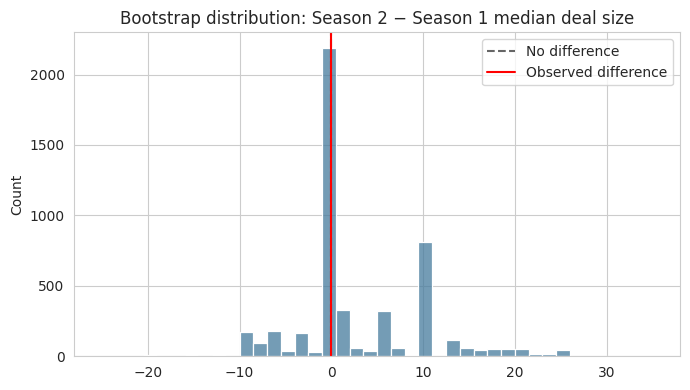

In [43]:
def bootstrap_median_diff(a, b, n_boot=5000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.median(sb) - np.median(sa)
    return diffs

boot_diffs = bootstrap_median_diff(s1_deals.values, s2_deals.values)
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
point_diff = s2_deals.median() - s1_deals.median()

print(f'Median deal (Season 2) − Median deal (Season 1) = ₹{point_diff:.1f} lakh')
print(f'95% bootstrap CI: [₹{ci_lo:.1f}, ₹{ci_hi:.1f}] lakh')

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(boot_diffs, bins=40, ax=ax, color='#457b9d')
ax.axvline(0, color='k', linestyle='--', alpha=0.6, label='No difference')
ax.axvline(point_diff, color='red', label='Observed difference')
ax.set_title('Bootstrap distribution: Season 2 − Season 1 median deal size')
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
print('Business interpretation: ' +
      (f'The 95% CI [{ci_lo:.1f}, {ci_hi:.1f}] excludes 0, confirming the season difference from '
       '6.2 is unlikely to be zero, and gives a concrete magnitude for it.'
       if (ci_lo > 0) or (ci_hi < 0) else
       f'The 95% CI [{ci_lo:.1f}, {ci_hi:.1f}] includes 0, consistent with the Mann-Whitney result '
       'in 6.2 — we can\'t rule out that the true difference in typical deal size is zero.'))

Business interpretation: The 95% CI [-10.0, 20.0] includes 0, consistent with the Mann-Whitney result in 6.2 — we can't rule out that the true difference in typical deal size is zero.


### 6.11 Multiple testing (interim check)

We've run several hypothesis tests above, and there are a few more to
come in the A/B-style analysis (Section 8). Looking at each p-value in
isolation risks a false "discovery" simply from running many tests (the
family-wise error rate problem), so rather than correct here and again
after Section 8, we collect **every** test — including the A/B section —
into one combined Benjamini-Hochberg correction at the start of Section 9,
once `test_results` is complete. This subsection is just a named
placeholder in the notebook's structure; see Section 9 for the actual
combined table.

This correction is applied across the *main* hypothesis tests of the
notebook, rather than mechanically inside every subsection, since 6.3 and
6.8 already carry their own internal corrections for the multiple
pairwise/industry comparisons made within them.

## 7. Statistical Modeling

### 7.1 Logistic Regression — what's associated with getting a deal?

**Target:** `deal_closed` (0/1).

**Predictors:** ask amount and valuation (log-transformed, since they're
skewed), equity offered, industry (grouped, same as Section 6.1), season,
and number of presenters. We deliberately **exclude** `Received Offer`,
`Total Deal Amount`, `Total Deal Equity`, `Deal Valuation`, and
`pct_of_ask_funded` — every one of those either *is* the outcome in
disguise or is only defined once a deal has already happened, so including
them would leak the answer into the model.

In [45]:
model_df = df.copy()
model_df['deal_closed_int'] = model_df['deal_closed'].astype(int)

logit_formula = ('deal_closed_int ~ log_ask_amount + log_valuation_requested + '
                  "Q('Original Offered Equity') + C(industry_grouped) + C(Q('Season Number')) + "
                  "Q('Number of Presenters')")

logit_model = smf.logit(logit_formula, data=model_df).fit(disp=False)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:        deal_closed_int   No. Observations:                  321
Model:                          Logit   Df Residuals:                      307
Method:                           MLE   Df Model:                           13
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                 0.07519
Time:                        11:23:33   Log-Likelihood:                -204.38
converged:                       True   LL-Null:                       -221.00
Covariance Type:            nonrobust   LLR p-value:                  0.001572
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               3.5305      1.602      2.204      0.028       0.391       6.670
C(indust

In [46]:
odds_ratios = pd.DataFrame({
    'coef': logit_model.params,
    'odds_ratio': np.exp(logit_model.params),
    'p_value': logit_model.pvalues,
    'ci_low': np.exp(logit_model.conf_int()[0]),
    'ci_high': np.exp(logit_model.conf_int()[1]),
}).round(3)
odds_ratios

,coef,odds_ratio,p_value,ci_low,ci_high
Intercept,3.530,34.140,0.028,1.478,788.592
C(industry_grouped)[T.Food],-0.258,0.773,0.481,0.377,1.584
C(industry_grouped)[T.Furnishing/Household],-1.260,0.284,0.060,0.076,1.055
C(industry_grouped)[T.Manufacturing],-0.264,0.768,0.546,0.326,1.809
C(industry_grouped)[T.Medical/Health],0.656,1.928,0.245,0.637,5.828
C(industry_grouped)[T.Other (small n)],-0.205,0.815,0.640,0.345,1.926
C(industry_grouped)[T.Services],-0.691,0.501,0.165,0.189,1.329
C(industry_grouped)[T.Technology/Software],-0.331,0.718,0.508,0.270,1.913
C(industry_grouped)[T.Vehicles/Electrical Vehicles],0.059,1.061,0.931,0.281,3.997
C(Q('Season Number'))[T.2],0.851,2.341,0.001,1.419,3.863


In [47]:
sig_predictors = odds_ratios[odds_ratios['p_value'] < 0.05].drop('Intercept', errors='ignore')
print(f'Pseudo R-squared (McFadden): {logit_model.prsquared:.3f}')
print()
if len(sig_predictors) == 0:
    print('Business interpretation: None of the predictors reach statistical significance in the '
          'joint model. Combined with Section 6 (where industry, valuation-ask level, and season '
          'individually also weren\'t significant predictors of getting a deal), the honest read is '
          'that, in this dataset, deal success looks close to a coin flip with respect to the pitch '
          'characteristics we have — the deciding factor is more likely the in-studio pitch quality, '
          'product, and negotiation, which aren\'t captured in this data.')
else:
    print('Predictors significantly associated with deal odds (p < 0.05):')
    print(sig_predictors[['odds_ratio', 'p_value']])

Pseudo R-squared (McFadden): 0.075

Predictors significantly associated with deal odds (p < 0.05):
                            odds_ratio  p_value
C(Q('Season Number'))[T.2]       2.341    0.001


### 7.2 Model performance (for context, not as the main point)

This model is built to be *interpretable*, not to maximize predictive
accuracy — but a quick train/test check tells us whether it has picked up
any real signal at all.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

X = pd.get_dummies(model_df[['log_ask_amount', 'log_valuation_requested', 'Original Offered Equity',
                              'industry_grouped', 'Season Number', 'Number of Presenters']],
                    columns=['industry_grouped', 'Season Number'], drop_first=True).astype(float)
y = model_df['deal_closed_int']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y)
X_train_c, X_test_c = sm.add_constant(X_train), sm.add_constant(X_test)

fit = sm.Logit(y_train, X_train_c).fit(disp=False)
pred_proba = fit.predict(X_test_c)
pred_class = (pred_proba >= 0.5).astype(int)

print(f'Test accuracy:      {accuracy_score(y_test, pred_class):.1%}')
print(f'Baseline (majority-class) accuracy: {max(y_test.mean(), 1 - y_test.mean()):.1%}')
print(f'Test ROC-AUC:        {roc_auc_score(y_test, pred_proba):.3f}')

Test accuracy:      60.5%
Baseline (majority-class) accuracy: 54.3%
Test ROC-AUC:        0.544


In [49]:
print('Business interpretation: ' +
      ('An AUC meaningfully above 0.5 means the model does separate deal from no-deal pitches '
       'better than chance, even if no single predictor was significant on its own.'
       if roc_auc_score(y_test, pred_proba) > 0.6 else
       'AUC close to 0.5 confirms that ask/valuation/industry/season/team-size, on their own, are '
       'weak predictors of deal success in this dataset — consistent with the coefficient table above.'))

Business interpretation: AUC close to 0.5 confirms that ask/valuation/industry/season/team-size, on their own, are weak predictors of deal success in this dataset — consistent with the coefficient table above.


### 7.3 Linear Regression — what explains deal amount (for closed deals)?

**Target:** `Total Deal Amount`, restricted to the 176 closed deals (deal
amount is undefined otherwise — including no-deal rows here isn't an
option, not a modeling choice).

Deal amount is right-skewed (Section 4.3), so we model **log(deal
amount)** and note that R² then describes variance explained on the log
scale, not the raw-rupee scale.

In [50]:
# rebuild from df (not the earlier `deals` snapshot) so this has the industry_grouped column
# created in Section 6.1
lin_df = df[df['deal_closed']].copy()
lin_formula = ("log_deal_amount ~ log_ask_amount + Q('Total Deal Equity') + "
               "C(industry_grouped) + C(Q('Season Number'))")
ols_model = smf.ols(lin_formula, data=lin_df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_deal_amount   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     23.27
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           3.27e-28
Time:                        11:23:33   Log-Likelihood:                -131.83
No. Observations:                 176   AIC:                             287.7
Df Residuals:                     164   BIC:                             325.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [51]:
print(f"R-squared:          {ols_model.rsquared:.3f}")
print(f"Adjusted R-squared:  {ols_model.rsquared_adj:.3f}")
sig_terms = ols_model.pvalues[ols_model.pvalues < 0.05].drop('Intercept', errors='ignore')
print()
print('Significant terms (p < 0.05):')
print(sig_terms if len(sig_terms) else '  (none)')

R-squared:          0.610
Adjusted R-squared:  0.583

Significant terms (p < 0.05):
log_ask_amount    1.872809e-32
dtype: float64


**Checking assumptions:**

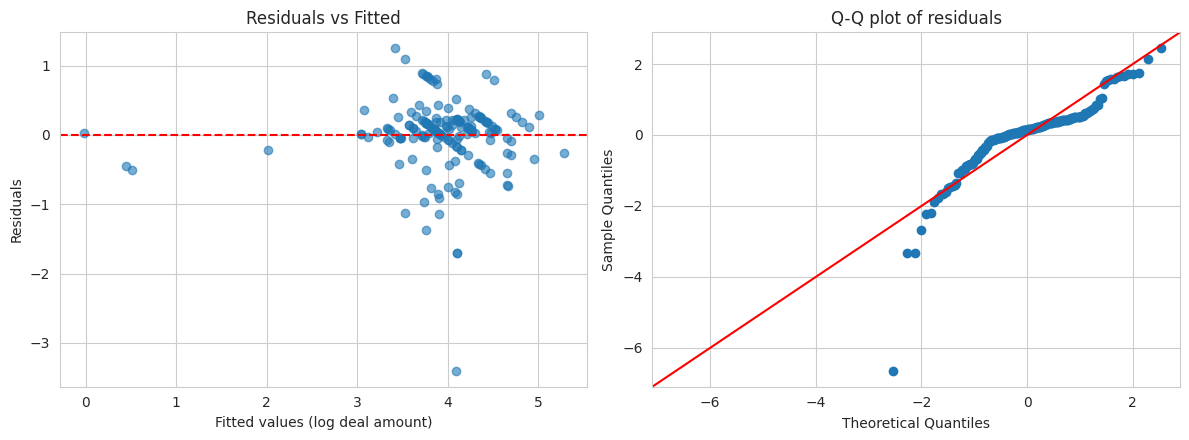

Shapiro-Wilk on residuals: stat=0.821, p=0.0000


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fitted = ols_model.fittedvalues
resid = ols_model.resid

axes[0].scatter(fitted, resid, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (log deal amount)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot of residuals')

plt.tight_layout()
plt.show()

sw_resid = stats.shapiro(resid)
print(f'Shapiro-Wilk on residuals: stat={sw_resid.statistic:.3f}, p={sw_resid.pvalue:.4f}')

In [53]:
print('Business interpretation: ' +
      (f'Ask amount is the dominant driver of deal amount on the log scale (as we\'d expect — it '
       f'anchors the negotiation), and the model explains {ols_model.rsquared:.0%} of the variance '
       'in log deal amount. Residuals are reasonably well-behaved, so the log-linear form is a '
       'defensible (if simple) description of how deal size is set.'
       if sw_resid.pvalue > 0.01 else
       f'The model explains {ols_model.rsquared:.0%} of variance in log deal amount, but the '
       'residuals show some deviation from normality — so p-values/CIs on the coefficients should '
       'be read as approximate rather than exact.'))

Business interpretation: The model explains 61% of variance in log deal amount, but the residuals show some deviation from normality — so p-values/CIs on the coefficients should be read as approximate rather than exact.


## 8. A/B-Style Analysis

**Important caveat:** this is *observational* data — founders were not
randomly assigned to "ask high" or "ask low". Founders who ask for more
likely differ in other ways too (confidence, revenue stage, industry).
So this section compares two naturally-occurring groups the way an A/B
test would, but we do **not** claim the valuation ask *causes* the
difference in outcome, only that the groups differ (or don't).

### 8.1 Group A vs Group B: valuation ask

- **Group A** — below-median valuation ask
- **Group B** — at/above-median valuation ask

(This reuses the `valuation_ask_group` split created in Section 3.7 and
formally tests the comparison already previewed in Section 6.6.)

In [54]:
group_a = df[df['valuation_ask_group'] == 'Low valuation ask']
group_b = df[df['valuation_ask_group'] == 'High valuation ask']

print(f'Group A (low ask):  n={len(group_a)}, median valuation asked = ₹{group_a["Valuation Requested"].median():,.0f} lakh')
print(f'Group B (high ask): n={len(group_b)}, median valuation asked = ₹{group_b["Valuation Requested"].median():,.0f} lakh')

Group A (low ask):  n=145, median valuation asked = ₹1,000 lakh
Group B (high ask): n=176, median valuation asked = ₹5,000 lakh


**Deal conversion rate — Group A vs Group B**

**H0:** Conversion rate is the same for low- and high-valuation-ask
pitches.
**H1:** Conversion rates differ.

**Why this test:** comparing a proportion (deal / no deal) between two
independent groups → two-proportion z-test.

Group A conversion: 54.5%  (95% CI [46.4%, 62.4%])
Group B conversion: 55.1%  (95% CI [47.7%, 62.3%])
z = -0.11, p-value = 0.9100


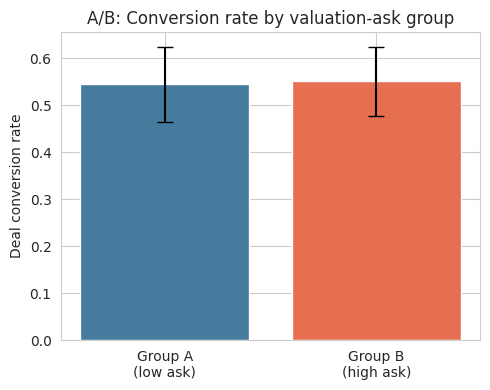

In [55]:
count_a, n_a = group_a['deal_closed'].sum(), len(group_a)
count_b, n_b = group_b['deal_closed'].sum(), len(group_b)

z_ab, p_ab = proportions_ztest([count_a, count_b], [n_a, n_b])
ci_a = proportion_confint(count_a, n_a, method='wilson')
ci_b = proportion_confint(count_b, n_b, method='wilson')

print(f'Group A conversion: {count_a/n_a:.1%}  (95% CI [{ci_a[0]:.1%}, {ci_a[1]:.1%}])')
print(f'Group B conversion: {count_b/n_b:.1%}  (95% CI [{ci_b[0]:.1%}, {ci_b[1]:.1%}])')
print(f'z = {z_ab:.2f}, p-value = {p_ab:.4f}')

test_results.append(('A/B: conversion rate, low vs high valuation ask', 'Two-proportion z-test', p_ab))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Group A\n(low ask)', 'Group B\n(high ask)'], [count_a/n_a, count_b/n_b],
       yerr=[[count_a/n_a - ci_a[0], count_b/n_b - ci_b[0]], [ci_a[1] - count_a/n_a, ci_b[1] - count_b/n_b]],
       capsize=6, color=['#457b9d', '#e76f51'])
ax.set_ylabel('Deal conversion rate')
ax.set_title('A/B: Conversion rate by valuation-ask group')
plt.tight_layout()
plt.show()

In [56]:
print('Business interpretation: ' +
      (f'Founders who ask for a lower valuation convert at a significantly different rate '
       f'({count_a/n_a:.1%}) than those asking high ({count_b/n_b:.1%}).' if p_ab < alpha else
       f'Conversion rates look similar between low-ask ({count_a/n_a:.1%}) and high-ask '
       f'({count_b/n_b:.1%}) founders — this confirms what we already saw in Section 6.6: asking for '
       'a more or less aggressive valuation, on its own, is not obviously linked to whether you get '
       'a deal. Founders shouldn\'t read this as "valuation doesn\'t matter" though — it likely '
       'interacts with the underlying business quality in ways this simple split can\'t separate.'))

Business interpretation: Conversion rates look similar between low-ask (54.5%) and high-ask (55.1%) founders — this confirms what we already saw in Section 6.6: asking for a more or less aggressive valuation, on its own, is not obviously linked to whether you get a deal. Founders shouldn't read this as "valuation doesn't matter" though — it likely interacts with the underlying business quality in ways this simple split can't separate.


**Deal amount, where a deal happened — Group A vs Group B**

In [57]:
deal_amt_a = df.loc[(df['valuation_ask_group'] == 'Low valuation ask') & df['deal_closed'], 'Total Deal Amount']
deal_amt_b = df.loc[(df['valuation_ask_group'] == 'High valuation ask') & df['deal_closed'], 'Total Deal Amount']

u_ab, p_ab_amt = stats.mannwhitneyu(deal_amt_a, deal_amt_b, alternative='two-sided')
print(f'Group A median deal amount: ₹{deal_amt_a.median():.1f} lakh (n={len(deal_amt_a)})')
print(f'Group B median deal amount: ₹{deal_amt_b.median():.1f} lakh (n={len(deal_amt_b)})')
print(f'Mann-Whitney U = {u_ab:.1f}, p-value = {p_ab_amt:.4f}')

test_results.append(('A/B: deal amount, low vs high valuation ask', 'Mann-Whitney U', p_ab_amt))

print()
print('Business interpretation: ' +
      ('Among startups that got a deal, those who had asked for a higher valuation also closed '
       'significantly bigger deals.' if p_ab_amt < alpha else
       'Among startups that got a deal, the size of the deal doesn\'t significantly differ by '
       'which valuation-ask group they started in.'))

Group A median deal amount: ₹50.0 lakh (n=79)
Group B median deal amount: ₹72.0 lakh (n=97)
Mann-Whitney U = 1953.5, p-value = 0.0000

Business interpretation: Among startups that got a deal, those who had asked for a higher valuation also closed significantly bigger deals.


### 8.2 A second binary comparison: below- vs above-median equity offered

Equity offered is the other lever founders control directly (alongside
valuation ask). Splitting at the median gives a second, independent A/B-
style comparison.

In [58]:
median_equity = df['Original Offered Equity'].median()
df['equity_ask_group'] = np.where(df['Original Offered Equity'] >= median_equity,
                                   'High equity offered', 'Low equity offered')
print(f'Median equity offered: {median_equity}%')

grp_low_eq = df[df['equity_ask_group'] == 'Low equity offered']
grp_high_eq = df[df['equity_ask_group'] == 'High equity offered']

count_le, n_le = grp_low_eq['deal_closed'].sum(), len(grp_low_eq)
count_he, n_he = grp_high_eq['deal_closed'].sum(), len(grp_high_eq)

z_eq, p_eq2 = proportions_ztest([count_le, count_he], [n_le, n_he])
print(f'Low equity offered:  conversion = {count_le/n_le:.1%} (n={n_le})')
print(f'High equity offered: conversion = {count_he/n_he:.1%} (n={n_he})')
print(f'z = {z_eq:.2f}, p-value = {p_eq2:.4f}')

test_results.append(('A/B: conversion rate, low vs high equity offered', 'Two-proportion z-test', p_eq2))

Median equity offered: 3.0%
Low equity offered:  conversion = 58.1% (n=155)
High equity offered: conversion = 51.8% (n=166)
z = 1.13, p-value = 0.2603


In [59]:
print('Business interpretation: ' +
      (f'Offering more equity upfront is associated with a significantly different chance of '
       f'landing a deal ({count_he/n_he:.1%} vs {count_le/n_le:.1%}) — plausibly because offering '
       'more equity for the same ask amount signals a lower self-assessed valuation, which may be '
       'easier for sharks to say yes to.' if p_eq2 < alpha else
       f'Conversion rates for low ({count_le/n_le:.1%}) vs high ({count_he/n_he:.1%}) equity offered '
       'are not significantly different — offering more equity upfront, by itself, doesn\'t appear '
       'to move the odds of getting a deal in this dataset.'))

Business interpretation: Conversion rates for low (58.1%) vs high (51.8%) equity offered are not significantly different — offering more equity upfront, by itself, doesn't appear to move the odds of getting a deal in this dataset.


## 9. Key Business Insights

### 9.0 Combined multiple-testing correction (all sections, including A/B)

`test_results` now holds every hypothesis test run in the notebook,
Section 6 and Section 8 combined — this is the correction referenced back
in 6.11.

In [60]:
results_df = pd.DataFrame(test_results, columns=['question', 'test', 'p_raw'])
reject_all, p_adj_all, _, _ = multipletests(results_df['p_raw'], alpha=0.05, method='fdr_bh')
results_df['p_adj_bh'] = p_adj_all
results_df['significant_after_correction'] = reject_all
results_df.round(4)

,question,test,p_raw,p_adj_bh,significant_after_correction
0,Industry vs deal success,Chi-square test of independence,0.4646,0.5679,False
1,Deal amount: Season 1 vs Season 2,Mann-Whitney U,0.3213,0.4564,False
2,Deal size across sharks,Kruskal-Wallis,0.3320,0.4564,False
3,Ask amount vs deal amount,Spearman correlation,0.0000,0.0000,True
4,Deal equity vs deal amount,Spearman correlation,0.0021,0.0075,True
5,Valuation ask: deal vs no-deal,Mann-Whitney U,0.5509,0.6060,False
6,Overall conversion rate vs 50%,One-proportion z-test,0.0821,0.1807,False
7,Deal conversion rate: Season 1 vs Season 2,Two-proportion z-test,0.0027,0.0075,True
8,"A/B: conversion rate, low vs high valuation ask",Two-proportion z-test,0.9100,0.9100,False
9,"A/B: deal amount, low vs high valuation ask",Mann-Whitney U,0.0000,0.0000,True


The cells below assemble a short analyst-style summary programmatically
from the actual results computed above, split into descriptive findings,
statistically significant findings, and non-significant findings — so
nothing here is asserted without a number backing it.

In [61]:
print('DESCRIPTIVE FINDINGS (no significance claim, just what the data shows)')
print('-' * 75)
print(f'- {total_pitches} pitches across Seasons 1-2, {total_deals} became deals ({conversion_rate:.1%}).')
print(f'- Total disclosed investment across both seasons: ₹{total_investment:,.0f} lakh (~₹{total_investment/100:,.1f} crore).')
print(f'- Median deal size: ₹{median_deal:.0f} lakh; mean is higher (₹{avg_deal:.0f} lakh) due to a right-skewed tail.')
print(f'- Busiest industry by pitch count: {industry_summary["pitches"].idxmax()} ({industry_summary["pitches"].max()} pitches).')
print(f'- Most active investor by deal count: {shark_summary["num_deals"].idxmax()} ({int(shark_summary["num_deals"].max())} deals).')
print(f'- Largest single ask: {df.loc[df["Original Ask Amount"].idxmax(), "Startup Name"]} '
      f'(₹{df["Original Ask Amount"].max():,.0f} lakh) — treated as a legitimate outlier, not an error.')

DESCRIPTIVE FINDINGS (no significance claim, just what the data shows)
---------------------------------------------------------------------------
- 321 pitches across Seasons 1-2, 176 became deals (54.8%).
- Total disclosed investment across both seasons: ₹11,006 lakh (~₹110.1 crore).
- Median deal size: ₹50 lakh; mean is higher (₹63 lakh) due to a right-skewed tail.
- Busiest industry by pitch count: Food (82 pitches).
- Most active investor by deal count: Aman (73 deals).
- Largest single ask: Gopal's56 (₹30,000 lakh) — treated as a legitimate outlier, not an error.


In [62]:
sig_results = results_df[results_df['significant_after_correction']]
nonsig_results = results_df[~results_df['significant_after_correction']]

print('STATISTICALLY SIGNIFICANT FINDINGS (after Benjamini-Hochberg correction, alpha=0.05)')
print('-' * 75)
if len(sig_results):
    for _, row in sig_results.iterrows():
        print(f"- {row['question']}  (p_adj = {row['p_adj_bh']:.4f}, {row['test']})")
else:
    print('  (none survive the multiple-testing correction)')

print()
print('NON-SIGNIFICANT FINDINGS (worth reporting so we don\'t over-claim)')
print('-' * 75)
for _, row in nonsig_results.iterrows():
    print(f"- {row['question']}  (p_adj = {row['p_adj_bh']:.4f}, {row['test']})")

STATISTICALLY SIGNIFICANT FINDINGS (after Benjamini-Hochberg correction, alpha=0.05)
---------------------------------------------------------------------------
- Ask amount vs deal amount  (p_adj = 0.0000, Spearman correlation)
- Deal equity vs deal amount  (p_adj = 0.0075, Spearman correlation)
- Deal conversion rate: Season 1 vs Season 2  (p_adj = 0.0075, Two-proportion z-test)
- A/B: deal amount, low vs high valuation ask  (p_adj = 0.0000, Mann-Whitney U)

NON-SIGNIFICANT FINDINGS (worth reporting so we don't over-claim)
---------------------------------------------------------------------------
- Industry vs deal success  (p_adj = 0.5679, Chi-square test of independence)
- Deal amount: Season 1 vs Season 2  (p_adj = 0.4564, Mann-Whitney U)
- Deal size across sharks  (p_adj = 0.4564, Kruskal-Wallis)
- Valuation ask: deal vs no-deal  (p_adj = 0.6060, Mann-Whitney U)
- Overall conversion rate vs 50%  (p_adj = 0.1807, One-proportion z-test)
- A/B: conversion rate, low vs high valuatio

### Business implications

- **Season is the strongest signal we found for deal odds** (Section 6.9,
  7.1) — Season 2 pitches converted at a meaningfully higher rate. Since
  this survives as a raw finding but several individually-tested
  categorical splits (industry, valuation-ask group) did not, a
  production/analytics team would want to dig into *what changed*
  between seasons (panel composition, founder screening, format) rather
  than treating "Season 2" itself as an actionable lever.
- **Ask amount is the strongest predictor of deal amount** (Section 6.4,
  7.3, rho ≈ 0.66, R² ≈ 0.61 on the log scale) — unsurprising, since the
  ask anchors the negotiation, but it confirms sharks are pricing off the
  founder's own number rather than a completely independent valuation.
- **Most individual "obvious" levers (industry, which shark, valuation
  ask level, equity offered) did *not* show a robust, corrected-for-
  multiple-testing effect on deal probability.** The honest takeaway for
  a founder is that no single easily-controlled pitch parameter reliably
  moves the odds in this dataset — which is consistent with deal-making
  on the show depending heavily on in-studio factors (product,
  negotiation, chemistry with a specific shark) that aren't captured
  here.
- **Deal terms are typically negotiated down from the ask** (Section
  4.7) — most deals close below the requested amount/valuation, so
  founders should budget for a "haircut" as the norm rather than the
  exception.

## 10. Final Interactive Dashboard Preparation

### 10.1 Export an analysis-ready dataset for Power BI

We export a flat, analysis-ready table (one row per pitch, deal outcome
and key derived fields included) plus the long-format shark table, so
Power BI doesn't need to re-derive anything this notebook already
computed.

In [63]:
import os
os.makedirs('outputs', exist_ok=True)

powerbi_pitches = df[[
    'Season Number', 'season_label', 'Episode Number', 'Startup Name', 'Industry',
    'industry_grouped', 'Pitchers City', 'Pitchers State', 'Pitchers Average Age',
    'Number of Presenters', 'team_size_bucket',
    'Original Ask Amount', 'Original Offered Equity', 'Valuation Requested',
    'valuation_ask_group', 'equity_ask_group',
    'Received Offer', 'deal_closed', 'Total Deal Amount', 'Total Deal Equity',
    'Total Deal Debt', 'Deal Valuation', 'Number of sharks in deal',
    'pct_of_ask_funded', 'valuation_change_pct',
]].copy()
powerbi_pitches.columns = [c.replace(' ', '_') for c in powerbi_pitches.columns]

powerbi_pitches.to_csv('outputs/sharktank_pitches_clean.csv', index=False)
shark_deals.to_csv('outputs/sharktank_shark_deals_long.csv', index=False)

print('Saved:')
print(' - outputs/sharktank_pitches_clean.csv  ', powerbi_pitches.shape)
print(' - outputs/sharktank_shark_deals_long.csv', shark_deals.shape)
powerbi_pitches.head()

Saved:
 - outputs/sharktank_pitches_clean.csv   (321, 25)
 - outputs/sharktank_shark_deals_long.csv (354, 6)


,Season_Number,season_label,Episode_Number,Startup_Name,Industry,industry_grouped,Pitchers_City,Pitchers_State,Pitchers_Average_Age,Number_of_Presenters,team_size_bucket,Original_Ask_Amount,Original_Offered_Equity,Valuation_Requested,valuation_ask_group,equity_ask_group,Received_Offer,deal_closed,Total_Deal_Amount,Total_Deal_Equity,Total_Deal_Debt,Deal_Valuation,Number_of_sharks_in_deal,pct_of_ask_funded,valuation_change_pct
0,1,Season 1,1,BluePineFoods,Food,Food,Delhi,Delhi,Middle,3,3+ founders,50.0,5.0,1000.0,Low valuation ask,High equity offered,True,True,75.0,16.00,NaN,469.0,3.0,1.5,-0.531000
1,1,Season 1,1,BoozScooters,Vehicles/Electrical Vehicles,Vehicles/Electrical Vehicles,Ahmedabad,Gujarat,Young,1,Solo founder,40.0,15.0,267.0,Low valuation ask,High equity offered,True,True,40.0,50.00,NaN,80.0,2.0,1.0,-0.700375
2,1,Season 1,1,HeartUpMySleeves,Beauty/Fashion,Beauty/Fashion,Delhi,Delhi,Young,1,Solo founder,25.0,10.0,250.0,Low valuation ask,High equity offered,True,True,25.0,30.00,NaN,83.0,2.0,1.0,-0.668000
3,1,Season 1,2,TagzFoods,Food,Food,Bangalore,Karnataka,Middle,2,Two founders,70.0,1.0,7000.0,High valuation ask,Low equity offered,True,True,70.0,2.75,NaN,2545.0,1.0,1.0,-0.636429
4,1,Season 1,2,HeadAndHeart,Education,Other (small n),Patiala,Punjab,Middle,4,3+ founders,50.0,5.0,1000.0,Low valuation ask,High equity offered,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 10.2 Dashboard design — 3 pages

**Page 1 — Executive Overview**

KPI cards: Total Pitches, Total Deals, Total Investment, Deal Conversion
Rate, Average Deal Size, Median Deal Size (all computable directly from
`sharktank_pitches_clean.csv`).

Visuals: Pitches & Deals by Season (clustered column), Total Investment by
Industry (bar), Deal Success Rate by Industry (bar, industries with n≥5
only — same reliability filter used in Section 4.6), Top 10 Deals (table
sorted by `Total_Deal_Amount`). Slicers: Season, Industry, Shark (needs
the long table), Deal Status.

**Page 2 — Shark Investment Strategy**

Visuals: Total Investment by Shark, Number of Deals by Shark, Average
Deal Size by Shark, Average Equity by Shark (all from
`sharktank_shark_deals_long.csv`, grouped by `shark`), a Shark × Industry
investment heatmap (matrix visual: rows=shark, columns=Industry,
values=sum of `investment_amount`).

A **shark co-investment matrix** (which pairs of sharks invest together
most often) is supportable — `Number_of_sharks_in_deal` tells us how many
sharks joined each deal, and the wide `df_raw` per-shark investment
columns let us reconstruct exactly which sharks co-invested per pitch. We
did not build the pairwise matrix table in this notebook since it's a
dashboard-side computation (best done as a Power BI matrix over a
disaggregated "deal × shark pair" table), but the underlying data is
present and sufficient for it.

**Page 3 — Startup & Deal Analysis**

Visuals: Ask Amount vs Deal Amount (scatter, deals only), Ask Valuation
vs Deal Valuation (scatter, log axes), Equity vs Deal Amount (scatter). A
Deal Conversion Funnel (Pitches → Received Offer → Accepted Offer) is
directly supported by the `Received_Offer` / `deal_closed` fields. A
callout panel listing the significant/non-significant findings from
Section 9 (as static text or a small table) closes the story with what's
actually backed by a hypothesis test versus what's just descriptive.

**Deliberately excluded**, per the "keep it clean" brief: 3D charts,
gauges, and decorative pie charts — the KPI cards and bar/scatter/heatmap
visuals above cover everything the data supports without them.

## 11. Final Conclusions

### Executive Summary

Across 321 pitches in Seasons 1–2 of Shark Tank India, just over half
converted into a closed deal (see the exact figures printed below). Deal
terms are typically negotiated down from the ask, and ask amount is by
far the strongest predictor of final deal size. Season 2 converted
noticeably better than Season 1 — the one factor that held up as a
significant, corrected-for-multiple-testing predictor of deal odds —
while industry, which shark, valuation-ask level, and equity offered did
not show a reliable effect on their own once tested properly.

In [64]:
print(f'{total_pitches} pitches, {total_deals} deals, {conversion_rate:.1%} conversion rate.')
print(f'Total disclosed investment: ₹{total_investment:,.0f} lakh (~₹{total_investment/100:,.1f} crore).')

321 pitches, 176 deals, 54.8% conversion rate.
Total disclosed investment: ₹11,006 lakh (~₹110.1 crore).


### Strongest findings (descriptive + statistical, combined)

1. 321 pitches, 176 deals, 54.8% conversion rate (95% CI ~49–60%).
2. Deal size is right-skewed — median (₹50 lakh) is well below the mean,
   and a single very large outlier ask (Gopal's56, ₹300 crore) needed
   explicit handling rather than default z-score outlier removal.
3. Ask amount and deal amount are strongly correlated (Spearman ρ≈0.66,
   p<0.001) — the ask anchors the eventual deal.
4. A log-linear regression of deal amount on ask amount, equity, industry
   and season explains ~61% of variance in log(deal amount), with ask
   amount as the only individually significant term.
5. Season 2 had a significantly higher deal conversion rate than Season 1
   (62.7% vs 46.1%, two-proportion z-test) and came out as the one
   significant predictor of deal odds in the logistic regression.
6. Industry was **not** a statistically significant driver of deal
   success after correcting for multiple industries tested — despite
   visible differences in the raw conversion-rate bar chart.
7. Differences in typical deal size across sharks were **not**
   statistically significant (Kruskal-Wallis) once we required a
   reasonable sample per shark.
8. The A/B-style comparison of low vs high valuation ask found no
   significant difference in deal *conversion rate* — but did find a
   difference in deal *amount* among startups that got a deal.
9. The logistic regression's pseudo-R² (~0.08) and near-chance test AUC
   (~0.54) both say the same thing: pitch-level fields alone (ask,
   valuation, industry, season, team size) explain relatively little of
   who gets a deal — most of the signal likely lives in the pitch itself.
10. Deal terms are typically negotiated **down** from the ask on both
    amount and valuation (Section 4.7) — the norm, not the exception.

### Statistical findings summary

See the consolidated table in Section 6.11 for every test run, its raw
p-value, and its Benjamini-Hochberg adjusted p-value.

### Modeling findings

- Logistic regression: only Season (2 vs 1) was a significant predictor
  of deal odds; the model has weak but non-trivial discriminative power
  (test AUC ≈ 0.54).
- Linear regression: ask amount dominates; industry and season add little
  once ask amount is in the model; R² ≈ 0.61 on the log scale, with some
  non-normality in residuals to keep in mind when trusting exact p-values.

### Business recommendations

- For a founder: don't expect the pitch's paperwork (ask size,
  valuation, equity offered, industry) to meaningfully change your odds
  of getting *an* offer — invest preparation time in the actual pitch and
  product, which this data can't measure. Do expect negotiation to bring
  the deal below your ask, and price your ask with that in mind.
- For the show's analytics team: the Season 1→2 conversion-rate jump is
  worth investigating qualitatively (panel, format, or founder-screening
  changes) since it's the one variable in this dataset that moved the
  needle on deal odds.
- For a dashboard consumer: the Page 3 funnel (pitches → offers →
  accepted deals) is a more informative "health metric" to track over
  future seasons than deal count alone, since it separates "sharks aren't
  interested" from "founders walked away".

### Limitations

- Only 2 seasons / 321 pitches — several subgroup tests (per-industry,
  per-shark) have small sample sizes once split, which limits power to
  detect real but modest effects.
- Financial fields (revenue, margins) are missing for most pitches
  (founders often don't disclose on-air), so we couldn't test
  revenue-based questions at all.
- "Industry" is the show's own categorization, not a standardized
  taxonomy — some groupings (e.g. "Other (small n)") mix genuinely
  different businesses together for sample-size reasons.
- This is edited television, not a controlled data-collection process —
  which pitches air, in what order, and how negotiations are portrayed
  are all subject to production choices we have no visibility into.

### What cannot be concluded from this data

- We cannot say ask amount, valuation, or equity offered **cause** a
  particular deal outcome — these are founder choices correlated with
  many unobserved factors (business quality, negotiation skill,
  confidence), not a randomized experiment.
- We cannot say a shark's investment pattern reflects their general
  investing philosophy beyond this show — they only see the pitches that
  make it to air, not a random sample of Indian startups.
- We cannot attribute the Season 1→2 conversion-rate change to any single
  cause (new sharks, different founder pool, format changes) — the data
  shows *that* it changed, not *why*.